In [1]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from typing import List, Dict
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('updated3.csv')

print("Column data types:")
print(df.dtypes)

# Check for non-numeric values in columns that should be numeric
numeric_columns = ['age', 'sets', 'reps', 'weight', 'frequency', 'protein', 'calories', 'sleep', 'muscle_size_increase_cm2']
for col in numeric_columns:
    if col in df.columns:
        non_numeric_mask = pd.to_numeric(df[col], errors='coerce').isna()
        if non_numeric_mask.any():
            problem_values = df.loc[non_numeric_mask, col].unique()
            print(f"⚠️ Column '{col}' contains non-numeric values: {problem_values}")
            
for col in df.columns:
    if col in ['age', 'sets']:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('float64')
    elif col in ['exercise_type', 'experience', 'target_muscle_group',  'gender',]:
        df[col] = df[col].astype(str)

Column data types:
age                           int64
gender                       object
exercise_type                object
sets                          int64
reps                          int64
weight                      float64
frequency                     int64
protein                     float64
calories                      int64
sleep                       float64
experience                   object
muscle_size_increase_cm2    float64
target_muscle_group          object
exercise_category            object
dtype: object


In [3]:


# Encode categorical variables
le_gender = LabelEncoder()
le_exercise = LabelEncoder()
le_experience = LabelEncoder()
le_muscle_group = LabelEncoder()
le_category = LabelEncoder()

df['gender'] = le_gender.fit_transform(df['gender'])
df['exercise_type'] = le_exercise.fit_transform(df['exercise_type'])
df['experience'] = le_experience.fit_transform(df['experience'])
df['target_muscle_group'] = le_muscle_group.fit_transform(df['target_muscle_group'])
df['exercise_category'] = le_category.fit_transform(df['exercise_category'])

# Define features and target
features = ['age', 'gender', 'exercise_type', 'sets', 'reps', 'weight', 
            'frequency', 'protein', 'calories', 'sleep', 'experience', 
            'target_muscle_group', 'exercise_category']
X = df[features]
y = df['muscle_size_increase_cm2']

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

print("Dataset loaded and model trained successfully.")
print(f"Features: {features}")
print(f"Sample data:\n{df.head()}")

Dataset loaded and model trained successfully.
Features: ['age', 'gender', 'exercise_type', 'sets', 'reps', 'weight', 'frequency', 'protein', 'calories', 'sleep', 'experience', 'target_muscle_group', 'exercise_category']
Sample data:
    age  gender  exercise_type  sets  reps  weight  frequency  protein  \
0  56.0       1              1   6.0    15   146.1          4     90.5   
1  46.0       1              1   3.0    13   155.6          5    192.4   
2  32.0       0              2   6.0     8   177.1          1    179.1   
3  25.0       1              2   6.0     7   110.0          1    175.0   
4  38.0       1              1   5.0    11   151.4          5    104.1   

   calories  sleep  experience  muscle_size_increase_cm2  target_muscle_group  \
0      2986    5.2           0                      1.84                    0   
1      2794    9.4           2                      4.61                    0   
2      2245    5.1           2                      4.72                    2 

In [4]:
# Define prediction function
def predict_multi_exercise_muscle_growth(age: int, gender: str, exercises: List[Dict], frequency: int, 
                                        protein: float, calories: int, sleep: float, experience: str) -> str:
    """
    Predict muscle growth (cm²) after 12 weeks for multiple exercises, grouped by target muscle group.
    
    Parameters:
    - age (int): Age in years (18–100)
    - gender (str): 'M' or 'F'
    - exercises (list of dicts): List of exercises, each with:
        - exercise_type (str): 'Squats', 'Bench Press', or 'Deadlifts'
        - sets (int): Number of sets (1–10)
        - reps (int): Number of reps (1–20)
        - weight (float): Weight lifted in kg (0–300)
        - target_muscle_group (str): 'Quads', 'Chest', or 'Back'
        - exercise_category (str): 'Compound' or 'Isolation'
    - frequency (int): Training days per week (1–7)
    - protein (float): Daily protein intake in grams (0–300)
    - calories (int): Daily calorie intake (0–5000)
    - sleep (float): Hours of sleep per night (0–24)
    - experience (str): 'Beginner', 'Intermediate', or 'Advanced'
    
    Returns:
    - str: Predicted muscle growth per muscle group (e.g., 'Quads growth: x cm²\nChest growth: y cm²')
    """
    try:
        # Define difficulty weights based on exercise category
        difficulty_weights = {
            'Compound': 1.0,
            'Isolation': 0.8
        }

        # Validate inputs
        if not (18 <= age <= 100):
            raise ValueError("Age must be between 18 and 100.")
        if gender not in le_gender.classes_:
            raise ValueError(f"Gender must be one of {list(le_gender.classes_)}.")
        if experience not in le_experience.classes_:
            raise ValueError(f"Experience level must be one of {list(le_experience.classes_)}.")
        if not (1 <= frequency <= 7):
            raise ValueError("Frequency must be between 1 and 7 days per week.")
        if not (0 < protein <= 300):
            raise ValueError("Protein intake must be between 0 and 300 grams.")
        if not (0 < calories <= 5000):
            raise ValueError("Calories must be between 0 and 5000 kcal.")
        if not (0 < sleep <= 24):
            raise ValueError("Sleep must be between 0 and 24 hours.")

        # Group exercises by target muscle group
        muscle_groups = {}
        for ex in exercises:
            if not isinstance(ex, dict):
                raise ValueError("Each exercise must be a dictionary with exercise_type, sets, reps, weight, target_muscle_group, and exercise_category.")
            if ex['exercise_type'] not in le_exercise.classes_:
                raise ValueError(f"Exercise type must be one of {list(le_exercise.classes_)}.")
            if ex['target_muscle_group'] not in le_muscle_group.classes_:
                raise ValueError(f"Target muscle group must be one of {list(le_muscle_group.classes_)}.")
            if ex['exercise_category'] not in le_category.classes_:
                raise ValueError(f"Exercise category must be one of {list(le_category.classes_)}.")
            if not (1 <= ex['sets'] <= 10):
                raise ValueError("Sets must be between 1 and 10.")
            if not (1 <= ex['reps'] <= 20):
                raise ValueError("Reps must be between 1 and 20.")
            if not (0 < ex['weight'] <= 300):
                raise ValueError("Weight must be between 0 and 300 kg.")
            
            muscle_group = ex['target_muscle_group']
            if muscle_group not in muscle_groups:
                muscle_groups[muscle_group] = []
            muscle_groups[muscle_group].append(ex)

        # Predict growth for each muscle group
        results = []
        for muscle_group, ex_list in muscle_groups.items():
            total_volume = 0
            primary_exercise = None
            max_volume = 0
            for ex in ex_list:
                volume = ex['sets'] * ex['reps'] * ex['weight'] * difficulty_weights[ex['exercise_category']]
                total_volume += volume
                if volume > max_volume:
                    max_volume = volume
                    primary_exercise = ex

            # Convert total volume to equivalent sets, reps, weight
            equiv_sets = min(10, primary_exercise['sets'])
            equiv_reps = min(20, primary_exercise['reps'])
            equiv_weight = min(300, total_volume / (equiv_sets * equiv_reps))

            # Encode inputs
            gender_encoded = le_gender.transform([gender])[0]
            exercise_encoded = le_exercise.transform([primary_exercise['exercise_type']])[0]
            experience_encoded = le_experience.transform([experience])[0]
            muscle_group_encoded = le_muscle_group.transform([muscle_group])[0]
            category_encoded = le_category.transform([primary_exercise['exercise_category']])[0]

            # Create input array
            input_data = np.array([[age, gender_encoded, exercise_encoded, equiv_sets, equiv_reps, equiv_weight, 
                                   frequency, protein, calories, sleep, experience_encoded, 
                                   muscle_group_encoded, category_encoded]])

            # Predict
            prediction = model.predict(input_data)[0]
            num_exercises = len(ex_list)
            adjustment_factor = 1 + 0.1 * (num_exercises - 1)  # 10% boost per additional exercise
            prediction *= min(1.3, adjustment_factor)  # Cap at 30% boost
            results.append(f"{muscle_group} growth: {round(prediction, 2)} cm²")

        return "\n".join(results) if results else "No valid exercises provided."

    except Exception as e:
        return f"Error: {str(e)}"

# TEST PREDICTION HERE

In [ ]:
# Test the prediction function
exercises = [
    {'exercise_type': 'Squats', 'sets': 4, 'reps': 10, 'weight': 80, 'target_muscle_group': 'Quads', 'exercise_category': 'Compound'},
    {'exercise_type': 'Bench Press', 'sets': 3, 'reps': 8, 'weight': 60, 'target_muscle_group': 'Chest', 'exercise_category': 'Compound'},
    {'exercise_type': 'Deadlifts', 'sets': 3, 'reps': 6, 'weight': 100, 'target_muscle_group': 'Back', 'exercise_category': 'Compound'}
]

# 12 WEEKS PREDICTION

result = predict_multi_exercise_muscle_growth(
    age=30,
    gender='M',
    exercises=exercises,
    frequency=3,
    protein=140,
    calories=2800,
    sleep=8,
    experience='Beginner'
)

print("Prediction Results:")
print(result)

Prediction Results:
Quads growth: 3.9 cm²
Chest growth: 4.14 cm²
Back growth: 4.14 cm²


c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [6]:
import joblib
filename = "sizePredictor.pkl"
joblib.dump(model, filename)

joblib.dump(le_gender, 'le_gender.pkl')
joblib.dump(le_exercise, 'le_exercise.pkl')
joblib.dump(le_experience, 'le_experience.pkl')
joblib.dump(le_muscle_group, 'le_muscle_group.pkl')
joblib.dump(le_category, 'le_category.pkl')

['le_category.pkl']

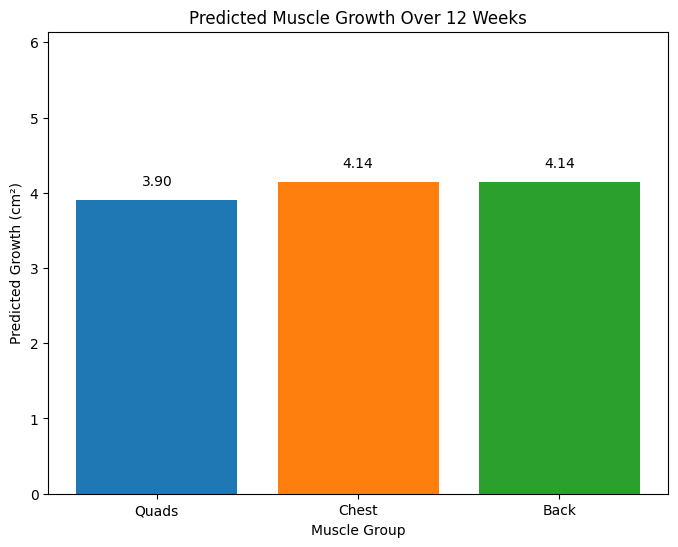

In [7]:
# Visualize predictions
def plot_muscle_growth(prediction_str: str):
    """Plot a bar chart of predicted muscle growth per muscle group."""
    if "Error" in prediction_str or not prediction_str:
        print("No valid predictions to plot.")
        return
    
    # Parse predictions
    muscle_groups = []
    growth_values = []
    for line in prediction_str.split("\n"):
        muscle, value = line.split(" growth: ")
        muscle_groups.append(muscle)
        growth_values.append(float(value.split(" cm²")[0]))

    # Create bar chart
    plt.figure(figsize=(8, 6))
    plt.bar(muscle_groups, growth_values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    plt.xlabel('Muscle Group')
    plt.ylabel('Predicted Growth (cm²)')
    plt.title('Predicted Muscle Growth Over 12 Weeks')
    plt.ylim(0, max(growth_values) + 2)
    for i, v in enumerate(growth_values):
        plt.text(i, v + 0.2, f"{v:.2f}", ha='center')
    plt.show()

plot_muscle_growth(result)